In [1]:
library(tidyr)
library(dplyr)
library(biomaRt)
library(stringr)
library(org.Mm.eg.db)
library(AnnotationDbi)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading

In [2]:
data <- readRDS("/mnt/lareaulab/reliscu/projects/Chronocell/data/janssens_2025_preprint/GSE279232_seuratObj_VBO_4-12.rds")

## Map gene and protein identfiers

In [3]:
antibods <- rownames(data$ADT)
antibods_matched <- antibods[toupper(antibods) %in% toupper(rownames(data$RNA))]

In [4]:
normalize_marker <- function(x){
  x <- str_replace_all(x, "^'+|'+$", "")
  x <- str_trim(x)

  # remove vendor/isotype/clone suffixes ONLY (keep biology parts like CD16-CD32, IA-IE, F4-80)
  x <- str_replace(x, "-(mh|Mouse-[A-Za-z]+|Rat-[A-Za-z]+|Hamster|A\\d+)$", "")

  # normalize common CD capitalization for matching
  ifelse(str_detect(x, "^CD\\d"), str_to_upper(x), x)
}

# ## things we should NOT split even though they have "-"
# do_not_split <- c("F4-80", "IA-IE", "Ly6A-Ly6E", "LY6A-LY6E", "CD45R-B220")

# ## split only CD##-CD## combos
# split_combo <- function(x){
#   if (x %in% do_not_split) return(x)
#   if (str_detect(x, "^CD\\d+-CD\\d+$")) unlist(str_split(x, "-", n = 2)) else x
# }


In [5]:
antibods_unmatched <- antibods[!antibods %in% antibods_matched]
antibods_clean <- normalize_marker(antibods_unmatched)

In [6]:
df <- data.frame(Orig_ID=antibods_unmatched, ID_clean=antibods_clean)

In [7]:
mart <- useEnsembl(
  biomart="genes",
  dataset="mmusculus_gene_ensembl",
  mirror="useast"
)

# Map synonyms -> mouse gene symbol
bm <- getBM(
  attributes=c("external_synonym", "mgi_symbol"),
  filters="external_synonym",
  values=df$ID_clean,
  mart=mart
) %>%
  distinct() %>%
  arrange(mgi_symbol, external_synonym)

In [8]:
df_mapped <- merge(x=df, y=bm, by.x="ID_clean", by.y="external_synonym", all.x=TRUE)

In [9]:
df_unmapped <- df_mapped %>% filter(is.na(mgi_symbol))

In [10]:
cols_want <- intersect(c("ALIAS","SYMBOL"), columns(org.Mm.eg.db))

map <- AnnotationDbi::select(
  org.Mm.eg.db,
  keys=df_unmapped$ID_clean,
  keytype="ALIAS",
  columns=cols_want
) |> distinct()

'select()' returned many:many mapping between keys and columns



In [11]:
df_mapped <- merge(df_mapped, map, by.x="ID_clean", by.y="ALIAS", all.x=TRUE)

In [12]:
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$mgi_symbol[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "mgi_symbol"]

In [13]:
df_unmapped <- df_mapped %>% filter(is.na(SYMBOL))

In [14]:
mg_res <- mygene::queryMany(
  unique(df_unmapped$ID_clean),
  scopes=c("alias","symbol","name"),
  fields=c("symbol","alias"),
  species="mouse",
  returnall=TRUE
)
mg_res_df <- data.frame(mg_res$response) %>% arrange(symbol)

Finished


In [15]:
df_mapped <- merge(df_mapped, mg_res_df, by.x="ID_clean", by.y="query", all.x=TRUE)

In [16]:
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$symbol[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "symbol"]

In [17]:
df_unmapped <- df_mapped %>% filter(is.na(SYMBOL))

In [18]:
library(dplyr)
library(tidyr)
library(purrr)
library(stringr)
library(AnnotationDbi)
library(org.Mm.eg.db)

## Make Jupyter show *all* rows/cols for plain data.frames too
options(
  repr.data.frame.max.rows = Inf,
  repr.data.frame.max.cols = Inf,
  repr.matrix.max.rows     = Inf,
  repr.matrix.max.cols     = Inf
)

symbols_all <- keys(org.Mm.eg.db, keytype = "SYMBOL")
sym_like <- function(rx) str_subset(symbols_all, regex(rx))

## 1) Multi-target / multi-subunit / “combo marker” expansions
multi_marker_map <- tibble::tribble(
  ~ID_clean,        ~SYMBOLS,
  "CD16-CD32",      list(c("Fcgr3", "Fcgr2b")),                  # CD16/32 antibody targets both :contentReference[oaicite:3]{index=3}
  "IA-IE",          list(c("H2-Aa","H2-Ab1","H2-Ea","H2-Eb1")),   # MHC-II I-A + I-E subunits :contentReference[oaicite:4]{index=4}
  "Ly6A-Ly6E",      list(c("Ly6a", "Ly6e")),
  "CD300C-D",       list(c("Cd300c", "Cd300c2")),                # vendor lists Gene IDs 387565/140497 :contentReference[oaicite:5]{index=5}
  "PIRA-PIRB",      list(c("Pirb", sym_like("^Pira")))           # Pirb + the Pira* family (cluster)
) %>%
  mutate(SYMBOLS = map(SYMBOLS, ~ unique(.x[!is.na(.x) & nzchar(.x)])))

## 2) “Family” markers (TCR variable-region families): expand to all matching genes
family_marker_regex <- c(
  "TCRb5" = "^Trbv5",
  "TCRb8" = "^Trbv8",
  "TCRg2" = "^Trgv2",
  "TCRg3" = "^Trgv3"
)

family_map <- imap_dfr(family_marker_regex, \(rx, id) {
  tibble(ID_clean = id, SYMBOLS = list(sym_like(rx)))
}) %>%
  filter(lengths(SYMBOLS) > 0)

multi_marker_map <- bind_rows(multi_marker_map, family_map) %>%
  group_by(ID_clean) %>%
  summarise(SYMBOLS = list(unique(unlist(SYMBOLS))), .groups = "drop")

## 3) Merge into your existing mapping results
## Assumes you already have `map` with columns: ID_clean and SYMBOL (and anything else you want to keep)
map2 <- df_unmapped %>%
  left_join(multi_marker_map, by = "ID_clean") %>%
  mutate(
    gene_symbols = pmap(list(SYMBOL, SYMBOLS), \(sym, syms) {
      if (!is.na(sym) && nzchar(sym)) return(sym)             # keep your single-gene mapping
      if (!is.null(syms) && length(syms) > 0) return(syms)    # fill from multi-gene expansion
      NA_character_
    })
  )


Attaching package: ‘purrr’


The following object is masked from ‘package:IRanges’:

    reduce




In [19]:
map2 <- map2[,c("ID_clean", "SYMBOLS")]

In [20]:
df_mapped <- merge(df_mapped, map2, by="ID_clean", all.x=TRUE)

In [21]:
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$SYMBOLS[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "SYMBOLS"]

In [22]:
manual_map <- c(
  "CD107A"="Lamp1",
  "CD107a"="Lamp1",
  "CD11A"="Itgal",
  "CD11a"="Itgal",
  "CD11B"="Itgam",
  "CD11b"="Itgam",
  "CD11C"="Itgax",
  "CD11c"="Itgax",
  "CD49F"="Itga6",
  "CD49f"="Itga6",
  "CD279"="Pdcd1",
  "CD366"="Havcr2",
  "CD137"="Tnfrsf9",
  "CD172A"="Sirpa",
  "CD172a"="Sirpa",
  "CD185"="Cxcr5",
  "CD192"="Ccr2",
  "CD201"="Procr",
  "CD204"="Msr1",
  "Mac2"="Lgals3",
  "MAC2"="Lgals3",
  "TER119"="Ly76",
  "TER-119"="Ly76",
  "CD193"="Ccr3",
  "CD196"="Ccr6",
  "CD270"="Tnfrsf14",
  "CD272"="Btla",
  "CD278"="Icos",
  "CD304"="Nrp1",
  "CD309"="Kdr",
  "CD314"="Klrk1",
  "CD357"="Tnfrsf18",
  "CD370"="Clec9a",
  "CD371"="Clec12a",
  "F4-80"="Adgre1",
  "FceRIa"="Fcer1a",
  "IL33Ra"="Il1rl1"
)

manual_df <- data.frame(ID_clean=names(manual_map), SYMBOL_man=manual_map)

In [23]:
df_mapped <- merge(df_mapped, manual_df, by="ID_clean", all.x=TRUE)

In [24]:
df_mapped$SYMBOL[unlist(lapply(df_mapped$SYMBOL, is.null))] <- NA
df_mapped$SYMBOL[is.na(df_mapped$SYMBOL)] <- df_mapped$SYMBOL_man[is.na(df_mapped$SYMBOL)]
df_mapped <- df_mapped[,!colnames(df_mapped) %in% "SYMBOL_man"]

In [25]:
df_mapped %>% filter(is.na(SYMBOL))

ID_clean,Orig_ID,SYMBOL,X_id,X_score,alias,notfound
<chr>,<chr>,<list>,<chr>,<dbl>,<list>,<lgl>
CD21-CD35,CD21-CD35,NA,NA,NA,,TRUE
CD45R-B220,CD45R-B220,NA,NA,NA,,TRUE
Panendothelial,Panendothelial,NA,NA,NA,,TRUE
ReceptorD4,ReceptorD4,NA,NA,NA,,TRUE
TCRgd,TCRgd,NA,NA,NA,,TRUE


In [26]:
df_mapped <- df_mapped %>%
  tidyr::unnest_longer(SYMBOL, values_to="Gene_symbol", keep_empty=TRUE) %>%
  tidyr::unnest_longer(alias, values_to="Alias", keep_empty=TRUE) %>%
  as.data.frame()

df_mapped

ID_clean,Orig_ID,Gene_symbol,X_id,X_score,Alias,notfound
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<lgl>
4-1BB,4-1BB,Tnfrsf9,NA,NA,NA,NA
CD102,CD102,Icam2,NA,NA,NA,NA
CD103,CD103,Itgae,NA,NA,NA,NA
CD105,CD105,Eng,NA,NA,NA,NA
CD106,CD106,Vcam1,NA,NA,NA,NA
CD107A,CD107a,Lamp1,16783,18.458517,CD107a,NA
CD107A,CD107a,Lamp1,16783,18.458517,LGP-120,NA
CD107A,CD107a,Lamp1,16783,18.458517,LGP-A,NA
CD107A,CD107a,Lamp1,16783,18.458517,Lamp-1,NA


In [27]:
df_mapped <- df_mapped[!is.na(df_mapped$Gene_symbol),]

In [28]:
df_mapped <- df_mapped[,c("Orig_ID", "Gene_symbol", "Alias")]

In [29]:
df_mapped <- rbind(
    df_mapped,
    data.frame(Orig_ID=antibods_matched, Gene_symbol=antibods_matched, Alias=NA)
)

In [30]:
# Source - https://stackoverflow.com/a
# Posted by alko989, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-18, License - CC BY-SA 4.0

firstup <- function(x) {
    x <- tolower(x)
    substr(x, 1, 1) <- toupper(substr(x, 1, 1))
    x
}


In [31]:
df_mapped$Gene_symbol <- unlist(lapply(df_mapped$Gene_symbol, firstup))

### Of mapped proteins, how many are in RNA data?

In [32]:
temp <- df_mapped$Gene_symbol[!df_mapped$Gene_symbol %in% rownames(data$RNA)]

temp

[1] "H2-aa"     "H2-ab1"    "H2-ea"     "H2-eb1"    "Igh-v7183" "Igh-vs107"
 [7] "Klra21"    "Mnotch"    "Pira1"     "Pira11"    "Pira4"     "Pira5"    
[13] "Pira6"     "Pira7"     "Pira9"     "Pira8"     "Pira12"    "Pira13"   
[19] "Pira2-ps1" "Pira2-ps2" "Siglecl1"  "Siglecl2"  "Siglecl2"  "Tcrb"     
[25] "Tcrb"      "Tcrg"      "Tcrg"      "Tcrg"      "Tcrg"      "Ly76"     
[31] "Ly76"

In [33]:
temp[!temp %in% rownames(data$RNA)] == temp

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[31] TRUE

In [34]:
# Not to bad. And doesn't look like including Alias yielded any additional matches.

In [35]:
df_mapped <- df_mapped %>%
    dplyr::select(-Alias) %>%
    filter(!duplicated(
        paste(Orig_ID, Gene_symbol)
    ))

In [36]:
df_mapped[!df_mapped$Gene_symbol %in% rownames(data$RNA),]

,Orig_ID,Gene_symbol
,<chr>,<chr>
163,IA-IE,H2-aa
164,IA-IE,H2-ab1
165,IA-IE,H2-ea
166,IA-IE,H2-eb1
169,IgG-Hamster,Igh-v7183
170,IgG-Hamster,Igh-vs107
227,Ly49H,Klra21
247,Notch,Mnotch
264,PIRA-PIRB,Pira1


In [37]:
df_mapped <- df_mapped %>%
    filter(Gene_symbol %in% rownames(data$RNA))

In [50]:
grep("^Cd2$", rownames(data$RNA@counts))

[1] 11679

## Look at correlation between RNA and protein

In [57]:
expr_RNA <- data$RNA@counts
expr_ADT <- data$ADT@counts 

In [62]:
expr_ADT_subset <- expr_ADT[match(df_mapped$Orig_ID, rownames(expr_ADT)),]
expr_RNA_subset <- expr_RNA[match(df_mapped$Gene_symbol, rownames(expr_RNA)),]

In [65]:
all.equal(rownames(expr_ADT_subset), df_mapped$Orig_ID)

[1] TRUE

In [66]:
all.equal(rownames(expr_RNA_subset), df_mapped$Gene_symbol)

[1] TRUE

In [90]:
mean_RNA <- Matrix::rowMeans(expr_RNA_subset)

In [92]:
corrs <- unlist(lapply(1:nrow(df_mapped), function(i) {
    cor(expr_RNA_subset[i,], expr_ADT_subset[i,])
}))

df <- data.frame(
    Protein=df_mapped$Orig_ID, 
    Gene=df_mapped$Gene_symbol, 
    Cor=corrs,
    Mean_RNA_expr=mean_RNA
)

Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation is zero”
Warning message in cor(expr_RNA_subset[i, ], expr_ADT_subset[i, ]):
“the standard deviation

In [96]:
df %>% arrange(-Cor) %>% head(20)

,Protein,Gene,Cor,Mean_RNA_expr
,<chr>,<chr>,<dbl>,<dbl>
1,CD8b,Cd8b1,0.4093074,0.03372560
2,CD150,Slamf1,0.3688977,0.08433973
3,CD63,Cd63,0.3555452,2.45452362
4,CD86,Cd86,0.3448704,5.04961917
5,CD200,Cd200,0.2875256,2.10834734
6,CD62L,Sell,0.2869103,0.08674992
7,CD80,Cd80,0.2841635,1.37529591
8,CD117,Kit,0.2677794,0.30859951
9,CD8a,Cd8a,0.2550202,2.10368134


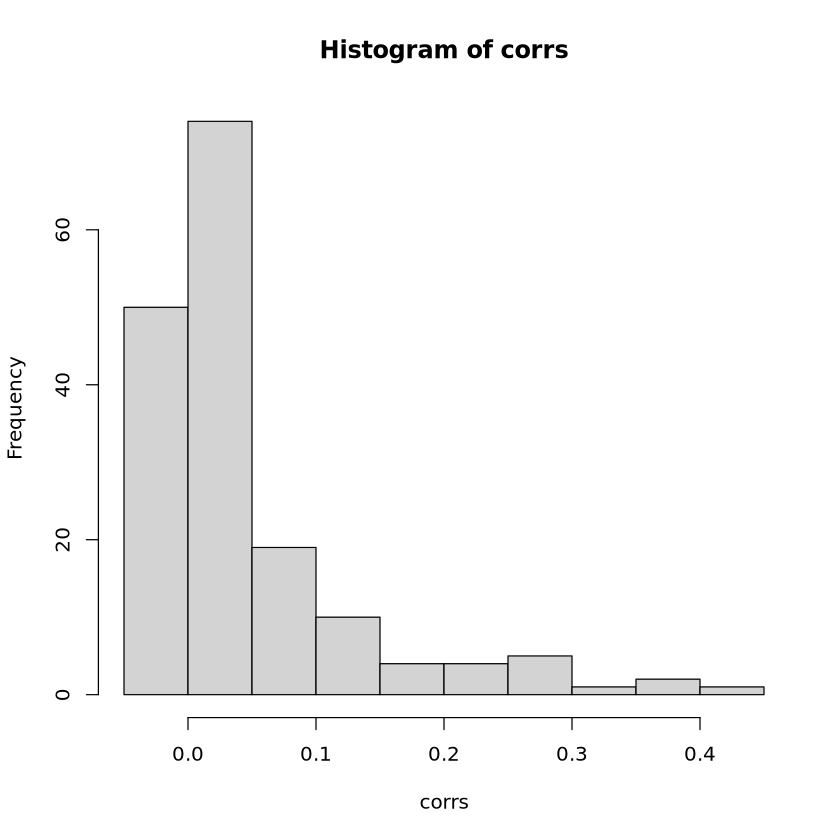

In [97]:
hist(corrs)

In [98]:
write.csv(df, file="RNA_vs_ADT_corr_meanExpr.csv", row.names=FALSE, quote=FALSE)